# 02 - Preprocessing Diagnostics (Maximum-Detail)

This notebook validates every step of the production preprocessing pipeline implemented in `src/preprocessing.py`. It is the bridge between **EDA** (notebook 01) and **modeling** (notebook 03).

## Objectives
- Verify every transformation in `src/preprocessing.py` works as intended.
- Prove the pipeline is **leakage-safe**: all statistics fit only on training data.
- Quantify the impact of each preprocessing step on the design matrix.
- Confirm encoding, scaling, and imbalance handling decisions match EDA findings.
- Produce a final **preprocessing contract** table summarizing every decision.

## EDA-driven contract (from notebook 01)

| Decision | EDA finding | Action here |
|---|---|---|
| `TotalCharges` cleaning | 11 blanks, all `tenure==0` | Coerce to numeric, median-impute (train-only) |
| Class imbalance | ~26.5% positives | Track ROC-AUC + PR-AUC, support `class_weight='balanced'` and SMOTE-in-CV |
| `Contract` encoding | Strong ordinality (Month-to-month > One year > Two year) | Use `OrdinalEncoder` |
| Other categoricals | Low cardinality (2–4) | One-hot encode |
| Numeric scaling | Heavy magnitude differences (`tenure` vs `TotalCharges`) | `StandardScaler` |
| Engineered features | Strong correlation in EDA | Add `Tenure_Years`, `Service_Count`, `Is_Fiber_Optic`, `Charges_Per_Service`, plus interactions |

## Sections
1. Setup and EDA-driven contract
2. Raw schema audit (replay)
3. Train/Test split strategy (leakage-safe)
4. `TotalCharges` cleaning diagnostics
5. Domain feature engineering verification
6. Engineered feature distributions
7. Encoding diagnostics (nominal, ordinal, OHE expansion)
8. Scaling diagnostics
9. ColumnTransformer assembly and shape audit
10. Imbalance handling diagnostics (class weights vs SMOTE-in-CV)
11. Leakage validation (train fit → test transform consistency)
12. Inference-payload smoke test
13. Memory and dtype audit
14. Final preprocessing contract table

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.preprocessing import (
    TARGET_COLUMN,
    ID_COLUMN,
    NOMINAL_COLUMNS,
    ORDINAL_COLUMNS,
    ORDINAL_CATEGORIES,
    SERVICE_COLUMNS,
    build_preprocessor,
    engineer_features,
    generate_data_quality_report,
    load_data,
    split_features_target,
)

DATA_PATH = REPO_ROOT / 'data' / 'raw' / 'telco.csv'
RANDOM_STATE = 42

df_raw = load_data(str(DATA_PATH))
print(f'Raw dataset shape: {df_raw.shape}')
display(df_raw.head())

Raw dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1) Raw Schema Audit (Replay)

We re-run the lightweight quality report from `src.preprocessing.generate_data_quality_report` so this notebook is self-contained and the diagnostic baseline is captured here.

In [2]:
quality_report = generate_data_quality_report(df_raw)
print(f"Rows: {quality_report['row_count']}")
print(f"Columns: {quality_report['column_count']}")
print(f"customerID is unique: {quality_report.get('customerID_is_unique', 'N/A')}")

schema_df = pd.DataFrame({
    'column': df_raw.columns,
    'dtype': df_raw.dtypes.astype(str).values,
    'n_unique': [df_raw[c].nunique(dropna=False) for c in df_raw.columns],
    'missing_count': [df_raw[c].isna().sum() for c in df_raw.columns],
})
schema_df['planned_role'] = schema_df['column'].map(
    lambda c: 'TARGET' if c == TARGET_COLUMN
    else ('ID' if c == ID_COLUMN
          else ('ORDINAL' if c in ORDINAL_COLUMNS
                else ('NOMINAL' if c in NOMINAL_COLUMNS else 'NUMERIC')))
)
display(schema_df)

Rows: 7043
Columns: 21
customerID is unique: True


,column,dtype,n_unique,missing_count,planned_role
0,customerID,object,7043,0,ID
1,gender,object,2,0,NOMINAL
2,SeniorCitizen,int64,2,0,NUMERIC
3,Partner,object,2,0,NOMINAL
4,Dependents,object,2,0,NOMINAL
5,tenure,int64,73,0,NUMERIC
6,PhoneService,object,2,0,NOMINAL
7,MultipleLines,object,3,0,NOMINAL
8,InternetService,object,3,0,NOMINAL
9,OnlineSecurity,object,3,0,NOMINAL


## 2) Train/Test Split Strategy (Leakage-Safe)

**Critical preprocessing principle**: every statistic (medians, scaler means/stds, encoder vocabularies) must be fitted on the **training split only**, then applied to the test split.

We perform stratified split here so subsequent diagnostics demonstrate this contract end-to-end.

,split,rows,positives,churn_rate
0,train,5634,1495,0.265353
1,test,1409,374,0.265436
2,total,7043,1869,0.265370


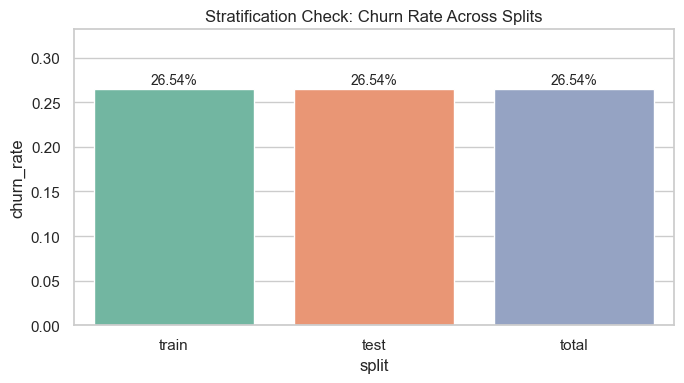

PASS: train/test churn rates within 1pp of each other.


In [3]:
engineered_full = engineer_features(df_raw)
prepared_full = split_features_target(engineered_full)
X_full, y_full = prepared_full.X, prepared_full.y

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_full,
)

split_summary = pd.DataFrame({
    'split': ['train', 'test', 'total'],
    'rows': [len(X_train), len(X_test), len(X_full)],
    'positives': [int(y_train.sum()), int(y_test.sum()), int(y_full.sum())],
    'churn_rate': [y_train.mean(), y_test.mean(), y_full.mean()],
})
display(split_summary)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=split_summary, x='split', y='churn_rate', palette='Set2', ax=ax)
for i, val in enumerate(split_summary['churn_rate']):
    ax.text(i, val + 0.005, f'{val:.2%}', ha='center', fontsize=10)
ax.set_title('Stratification Check: Churn Rate Across Splits')
ax.set_ylim(0, max(split_summary['churn_rate']) * 1.25)
plt.tight_layout()
plt.show()

assert abs(y_train.mean() - y_test.mean()) < 0.01, 'Stratification drifted!'
print('PASS: train/test churn rates within 1pp of each other.')

## 3) `TotalCharges` Cleaning Diagnostics

The EDA confirmed exactly 11 blank `TotalCharges` rows, all with `tenure == 0`. We now verify:

1. The `engineer_features` function coerces `TotalCharges` correctly.
2. Median imputation is computed **only on the train split** to avoid leakage.
3. The same train-median is applied to test rows (not test-median).
4. Imputed values are sensible (compared to no-impute baseline distribution).

Raw blanks coerced to NaN: 11
engineer_features TotalCharges NaN (train): 8
engineer_features TotalCharges NaN (test):  3

Train median (used for impute): 1398.12
Test median (for reference only): 1395.53
Median delta: 2.60

PASS: TotalCharges has no NaN after train-median imputation.


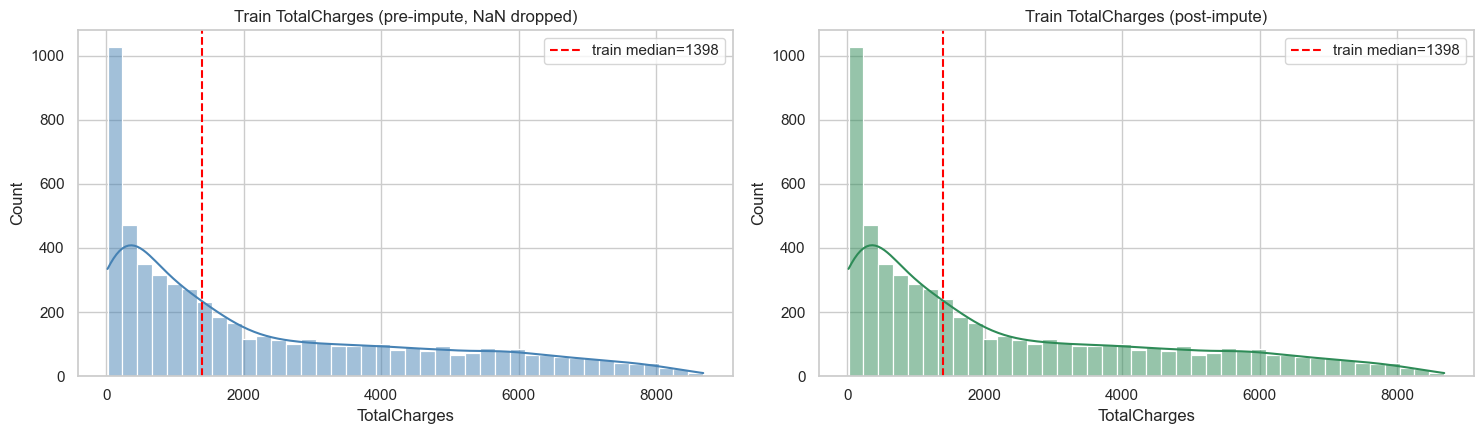

In [4]:
raw_total = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
print(f'Raw blanks coerced to NaN: {raw_total.isna().sum()}')
print(f'engineer_features TotalCharges NaN (train): {X_train["TotalCharges"].isna().sum()}')
print(f'engineer_features TotalCharges NaN (test):  {X_test["TotalCharges"].isna().sum()}')

train_median = X_train['TotalCharges'].median()
test_median_for_reference = X_test['TotalCharges'].median()
print(f'\nTrain median (used for impute): {train_median:.2f}')
print(f'Test median (for reference only): {test_median_for_reference:.2f}')
print(f'Median delta: {abs(train_median - test_median_for_reference):.2f}')

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
X_train_clean['TotalCharges'] = X_train_clean['TotalCharges'].fillna(train_median)
X_test_clean['TotalCharges'] = X_test_clean['TotalCharges'].fillna(train_median)

assert X_train_clean['TotalCharges'].isna().sum() == 0
assert X_test_clean['TotalCharges'].isna().sum() == 0
print('\nPASS: TotalCharges has no NaN after train-median imputation.')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.histplot(X_train['TotalCharges'].dropna(), bins=40, ax=axes[0], color='steelblue', kde=True)
axes[0].axvline(train_median, color='red', linestyle='--', label=f'train median={train_median:.0f}')
axes[0].set_title('Train TotalCharges (pre-impute, NaN dropped)')
axes[0].legend()

sns.histplot(X_train_clean['TotalCharges'], bins=40, ax=axes[1], color='seagreen', kde=True)
axes[1].axvline(train_median, color='red', linestyle='--', label=f'train median={train_median:.0f}')
axes[1].set_title('Train TotalCharges (post-impute)')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4) Domain Feature Engineering Verification

We unit-test each engineered feature created by `engineer_features`:
- `Tenure_Years`
- `Is_Fiber_Optic`
- `Service_Count`
- `Charges_Per_Service`
- `Contract_Tenure_Interaction`
- `MonthlyCharge_Tenure_Ratio`
- `SeniorCitizen_AloneRisk`
- `Paperless_AutoPay_Flag`

In [5]:
engineered_cols = [
    'Tenure_Years', 'Is_Fiber_Optic', 'Service_Count', 'Charges_Per_Service',
    'Contract_Tenure_Interaction', 'MonthlyCharge_Tenure_Ratio',
    'SeniorCitizen_AloneRisk', 'Paperless_AutoPay_Flag',
]

print('Engineered columns present in X_train:')
for col in engineered_cols:
    print(f'  - {col}: {col in X_train.columns}')

display(X_train[engineered_cols].describe().T)

assert (X_train['Tenure_Years'] * 12 - X_train['tenure']).abs().max() < 1e-9
print('\nPASS: Tenure_Years == tenure / 12.')

raw_train = df_raw.loc[X_train.index]
expected_fiber = (raw_train['InternetService'].str.lower() == 'fiber optic').astype(int)
assert (expected_fiber.values == X_train['Is_Fiber_Optic'].values).all()
print('PASS: Is_Fiber_Optic flag matches raw InternetService.')

assert X_train['Service_Count'].between(0, len(SERVICE_COLUMNS) + 1).all()
print(f'PASS: Service_Count in [0, {len(SERVICE_COLUMNS) + 1}].')

cps = X_train['MonthlyCharges'] / np.maximum(X_train['Service_Count'], 1)
assert np.allclose(cps.values, X_train['Charges_Per_Service'].values)
print('PASS: Charges_Per_Service formula consistent.')

assert X_train['SeniorCitizen_AloneRisk'].isin([0, 1]).all()
assert X_train['Paperless_AutoPay_Flag'].isin([0, 1]).all()
assert X_train['Is_Fiber_Optic'].isin([0, 1]).all()
print('PASS: Binary flags are strictly {0,1}.')

Engineered columns present in X_train:
  - Tenure_Years: True
  - Is_Fiber_Optic: True
  - Service_Count: True
  - Charges_Per_Service: True
  - Contract_Tenure_Interaction: True
  - MonthlyCharge_Tenure_Ratio: True
  - SeniorCitizen_AloneRisk: True
  - Paperless_AutoPay_Flag: True


,count,mean,std,min,25%,50%,75%,max
Tenure_Years,5634.0,2.707091,2.047395,0.000000,0.750000,2.416667,4.583333,6.00
Is_Fiber_Optic,5634.0,0.440717,0.496517,0.000000,0.000000,0.000000,1.000000,1.00
Service_Count,5634.0,4.167554,2.320947,1.000000,2.000000,4.000000,6.000000,9.00
Charges_Per_Service,5634.0,17.239616,5.355410,8.650000,12.933333,16.654167,20.062500,35.90
Contract_Tenure_Interaction,5634.0,13.665602,25.855317,0.000000,0.000000,0.000000,0.000000,72.00
MonthlyCharge_Tenure_Ratio,5634.0,8.609505,16.388984,0.268056,1.282206,2.143237,6.535119,101.45
SeniorCitizen_AloneRisk,5634.0,0.080405,0.271943,0.000000,0.000000,0.000000,0.000000,1.00
Paperless_AutoPay_Flag,5634.0,0.251331,0.433817,0.000000,0.000000,0.000000,1.000000,1.00



PASS: Tenure_Years == tenure / 12.
PASS: Is_Fiber_Optic flag matches raw InternetService.
PASS: Service_Count in [0, 9].
PASS: Charges_Per_Service formula consistent.
PASS: Binary flags are strictly {0,1}.


## 5) Engineered Feature Distributions and Churn Linkage

For each engineered feature we visualize:
- distribution shape on the training split
- relationship with churn (the actual signal we expect from EDA)

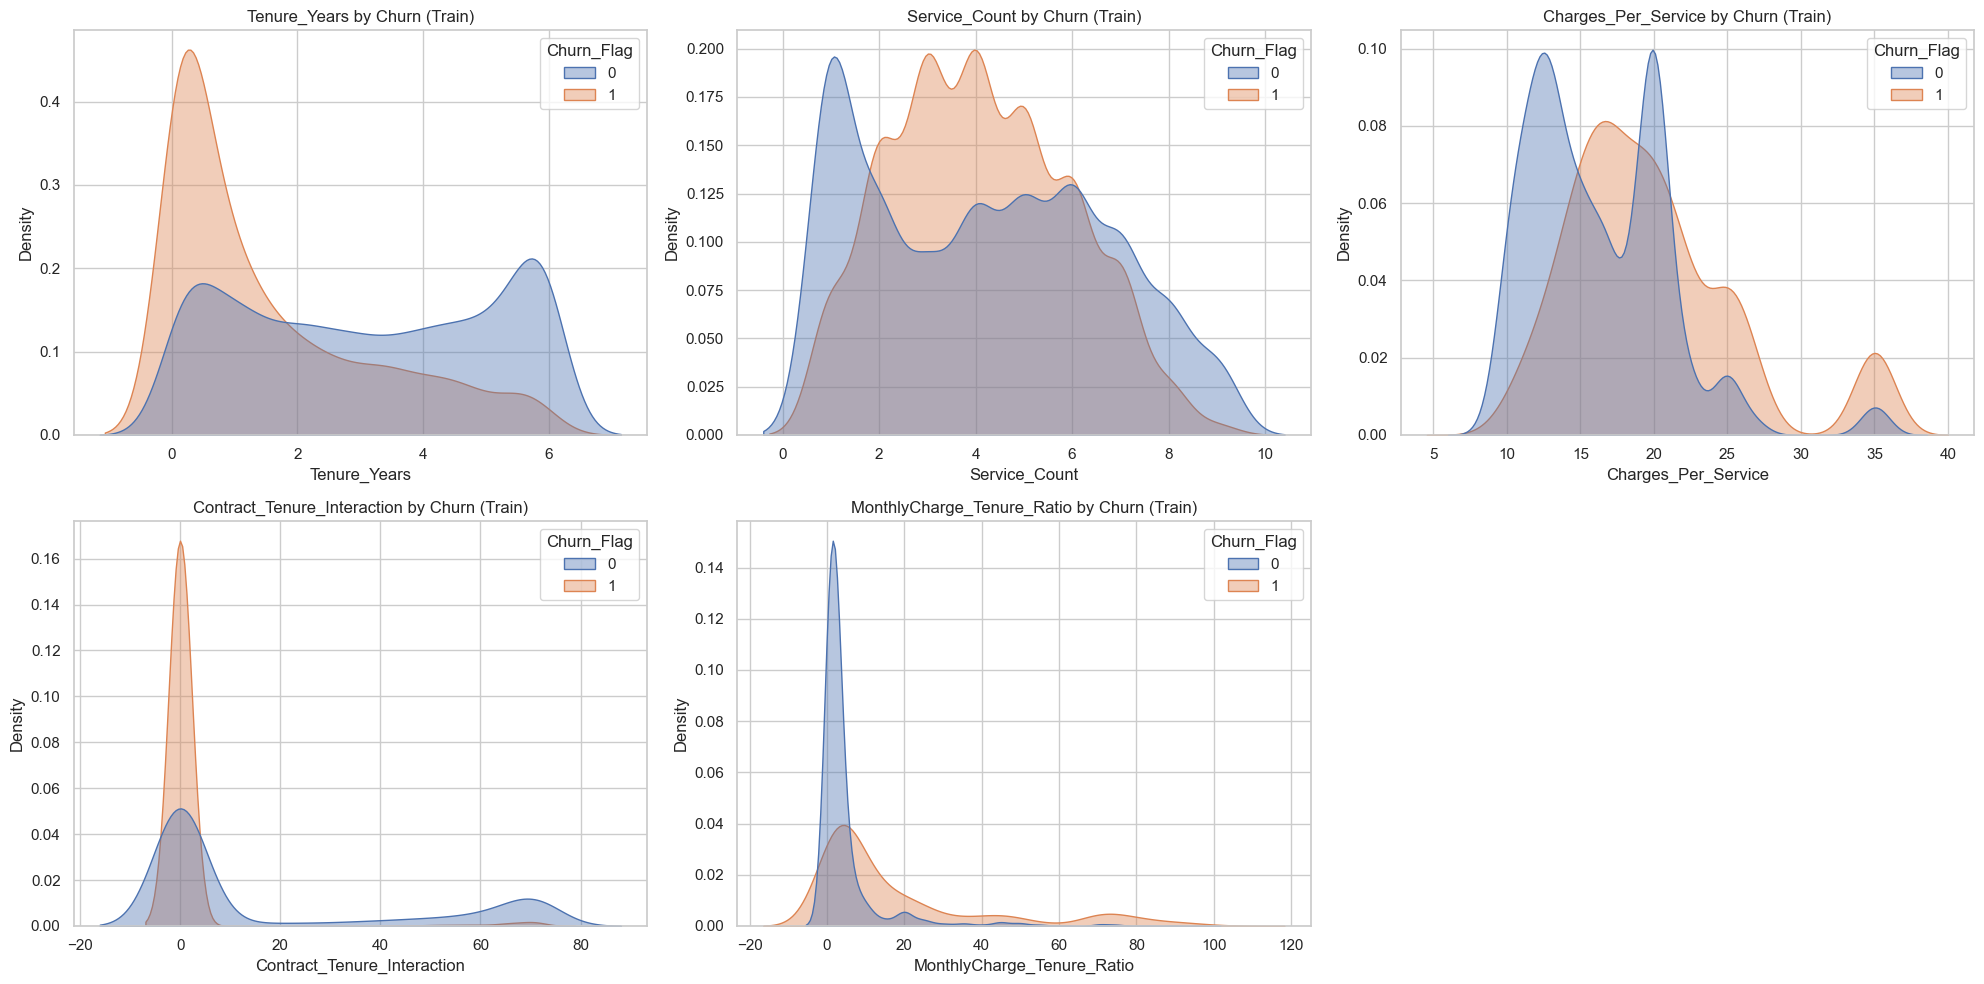

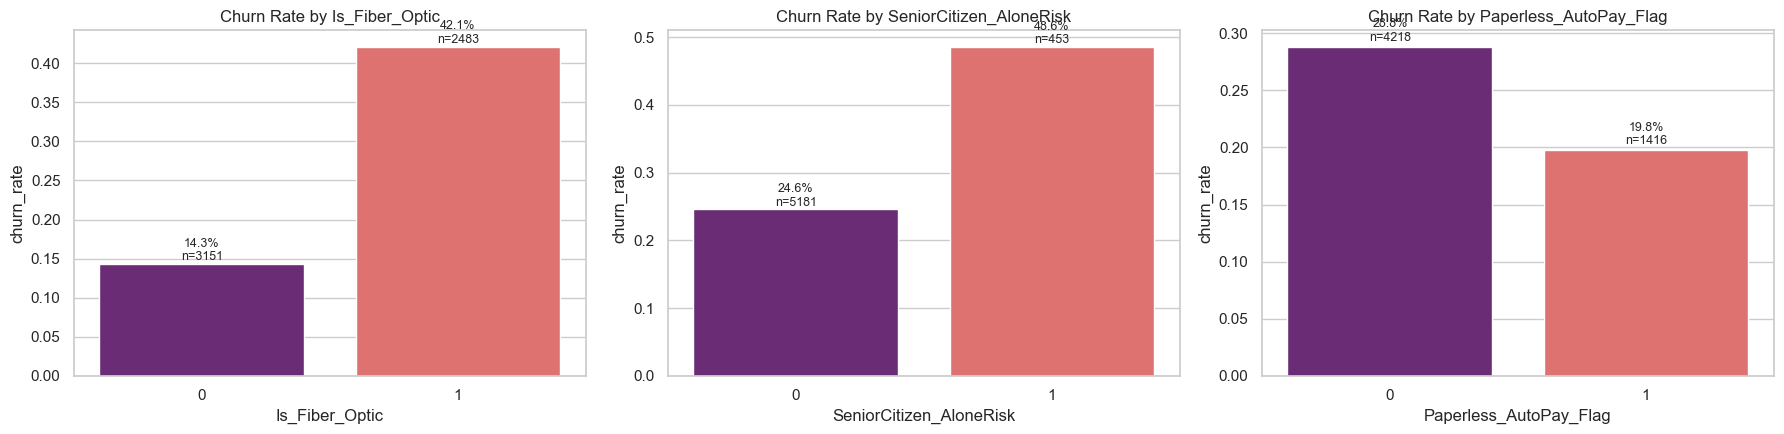

In [6]:
train_with_target = X_train.assign(Churn_Flag=y_train.values)

continuous_engineered = ['Tenure_Years', 'Service_Count', 'Charges_Per_Service',
                         'Contract_Tenure_Interaction', 'MonthlyCharge_Tenure_Ratio']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()
for ax, col in zip(axes, continuous_engineered):
    sns.kdeplot(
        data=train_with_target, x=col, hue='Churn_Flag',
        fill=True, common_norm=False, alpha=0.4, ax=ax
    )
    ax.set_title(f'{col} by Churn (Train)')
for ax in axes[len(continuous_engineered):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

binary_engineered = ['Is_Fiber_Optic', 'SeniorCitizen_AloneRisk', 'Paperless_AutoPay_Flag']
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, col in zip(axes, binary_engineered):
    rate_df = (
        train_with_target.groupby(col)['Churn_Flag']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'churn_rate', 'count': 'n'})
        .reset_index()
    )
    sns.barplot(data=rate_df, x=col, y='churn_rate', ax=ax, palette='magma')
    for i, (rate, n) in enumerate(zip(rate_df['churn_rate'], rate_df['n'])):
        ax.text(i, rate + 0.005, f'{rate:.1%}\nn={int(n)}', ha='center', fontsize=9)
    ax.set_title(f'Churn Rate by {col}')
plt.tight_layout()
plt.show()

## 6) Encoding Diagnostics

We confirm:
- Which columns end up nominal vs ordinal vs numeric.
- Cardinality per categorical variable.
- One-hot expansion math (number of new columns).
- Ordinal encoding for `Contract` matches the documented order: `Month-to-month=0 < One year=1 < Two year=2`.

In [7]:
available_nominal = [c for c in NOMINAL_COLUMNS if c in X_train.columns]
available_ordinal = [c for c in ORDINAL_COLUMNS if c in X_train.columns]
numerical_cols = [c for c in X_train.columns if c not in available_nominal + available_ordinal]

role_summary = pd.DataFrame({
    'role': (
        ['nominal'] * len(available_nominal)
        + ['ordinal'] * len(available_ordinal)
        + ['numerical'] * len(numerical_cols)
    ),
    'column': available_nominal + available_ordinal + numerical_cols,
})
role_summary['n_unique'] = role_summary['column'].map(lambda c: X_train[c].nunique(dropna=False))
role_summary['dtype'] = role_summary['column'].map(lambda c: str(X_train[c].dtype))
display(role_summary)

ohe_columns_added = sum(X_train[c].nunique(dropna=False) for c in available_nominal)
print(f'\nNominal feature count: {len(available_nominal)}')
print(f'Total OHE columns produced: {ohe_columns_added}')
print(f'Ordinal feature count: {len(available_ordinal)}')
print(f'Numerical feature count: {len(numerical_cols)}')

print(f'\nOrdinal categories declared: {ORDINAL_CATEGORIES}')
print(f"Train Contract value counts:\n{X_train['Contract'].value_counts()}")

,role,column,n_unique,dtype
0,nominal,gender,2,object
1,nominal,Partner,2,object
2,nominal,Dependents,2,object
3,nominal,PhoneService,2,object
4,nominal,MultipleLines,3,object
5,nominal,InternetService,3,object
6,nominal,OnlineSecurity,3,object
7,nominal,OnlineBackup,3,object
8,nominal,DeviceProtection,3,object
9,nominal,TechSupport,3,object



Nominal feature count: 14
Total OHE columns produced: 38
Ordinal feature count: 1
Numerical feature count: 12

Ordinal categories declared: [['Month-to-month', 'One year', 'Two year']]
Train Contract value counts:
Contract
Month-to-month    3102
Two year          1359
One year          1173
Name: count, dtype: int64


## 7) Scaling Diagnostics

`StandardScaler` is applied only to numerical columns inside the `ColumnTransformer`. We verify:
- Pre-scaling: numericals have very different scales (`tenure` ~ 0–72, `TotalCharges` ~ 0–8500).
- Post-scaling: each scaled feature has mean ~0 and std ~1 on the training split.
- The fitted scaler is then applied to test rows without re-fitting.

,pre_mean,pre_std,pre_min,pre_max,post_mean,post_std,post_min,post_max
tenure,32.4851,24.5687,0.0000,72.00,-0.0,1.0001,-1.3223,1.6085
MonthlyCharges,64.9300,30.1381,18.4000,118.75,-0.0,1.0001,-1.5440,1.7859
TotalCharges,2301.3200,2277.8088,18.8500,8684.80,-0.0,1.0001,-1.0021,2.8027
Tenure_Years,2.7071,2.0474,0.0000,6.00,-0.0,1.0001,-1.3223,1.6085
Service_Count,4.1676,2.3209,1.0000,9.00,-0.0,1.0001,-1.3649,2.0823
Charges_Per_Service,17.2396,5.3554,8.6500,35.90,0.0,1.0001,-1.6041,3.4847
MonthlyCharge_Tenure_Ratio,8.6095,16.3890,0.2681,101.45,-0.0,1.0001,-0.5090,5.6653



PASS: Post-scaling means ~ 0 and stds ~ 1 on training data.


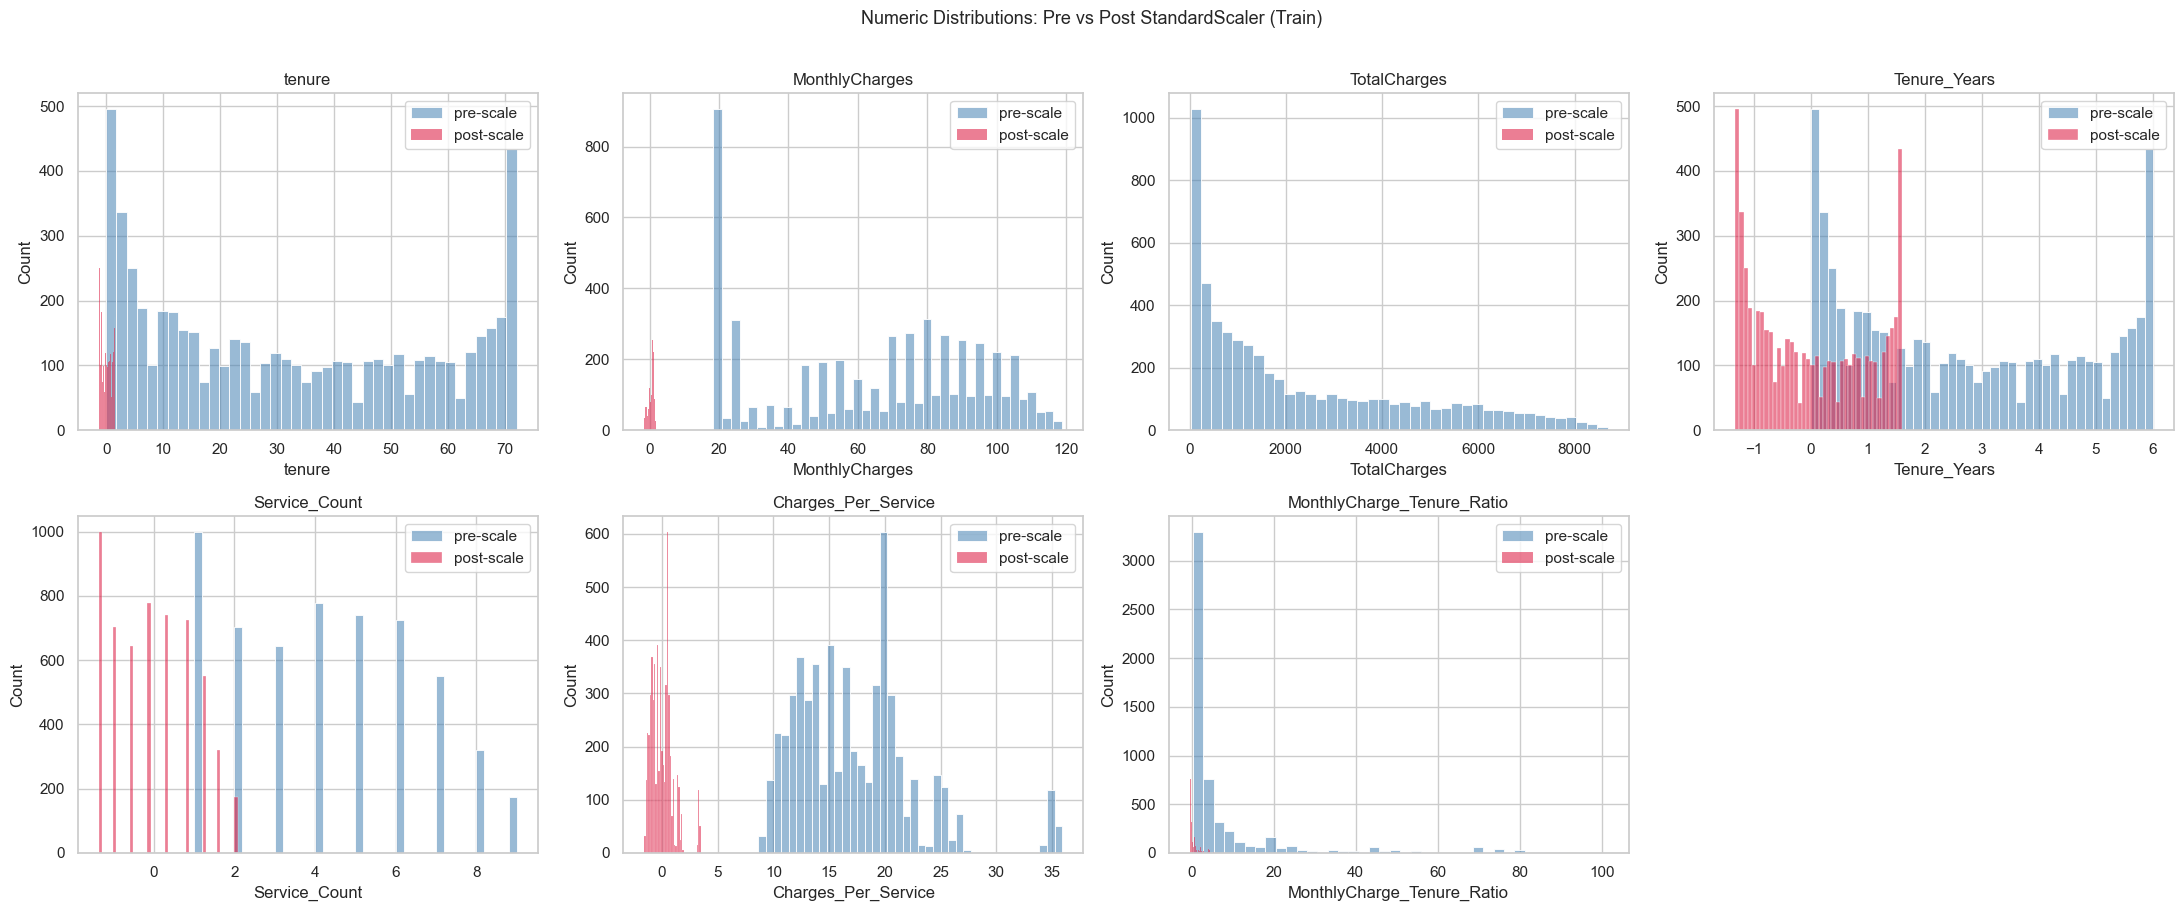

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

scaler_demo_cols = [c for c in ['tenure', 'MonthlyCharges', 'TotalCharges',
                                'Tenure_Years', 'Service_Count',
                                'Charges_Per_Service', 'MonthlyCharge_Tenure_Ratio']
                    if c in X_train.columns]

X_train_scaled_demo = X_train[scaler_demo_cols].copy()
imputer_demo = SimpleImputer(strategy='median')
X_train_scaled_demo[scaler_demo_cols] = imputer_demo.fit_transform(X_train_scaled_demo)
scaler_demo = StandardScaler().fit(X_train_scaled_demo)

pre_stats = X_train_scaled_demo.agg(['mean', 'std', 'min', 'max']).T.add_prefix('pre_')
post = pd.DataFrame(scaler_demo.transform(X_train_scaled_demo), columns=scaler_demo_cols)
post_stats = post.agg(['mean', 'std', 'min', 'max']).T.add_prefix('post_')
scaler_audit = pre_stats.join(post_stats).round(4)
display(scaler_audit)

assert np.allclose(post.mean().values, 0, atol=1e-6)
assert np.allclose(post.std(ddof=0).values, 1, atol=1e-6)
print('\nPASS: Post-scaling means ~ 0 and stds ~ 1 on training data.')

X_test_imputed = pd.DataFrame(imputer_demo.transform(X_test[scaler_demo_cols]),
                              columns=scaler_demo_cols, index=X_test.index)
X_test_scaled = pd.DataFrame(scaler_demo.transform(X_test_imputed),
                             columns=scaler_demo_cols, index=X_test.index)

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.flatten()
for ax_idx, col in enumerate(scaler_demo_cols):
    ax = axes[ax_idx]
    sns.histplot(X_train_scaled_demo[col], bins=40, ax=ax, color='steelblue', alpha=0.55, label='pre-scale')
    sns.histplot(post[col], bins=40, ax=ax, color='crimson', alpha=0.55, label='post-scale')
    ax.set_title(col)
    ax.legend()
for ax in axes[len(scaler_demo_cols):]:
    ax.axis('off')
plt.suptitle('Numeric Distributions: Pre vs Post StandardScaler (Train)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 8) ColumnTransformer Pipeline Assembly

We instantiate the production preprocessor via `build_preprocessor(X_train)` and verify:
- Transformer block list (numeric, nominal, ordinal).
- Output dimensionality and feature names.
- That fit-then-transform on train/test produces consistent column structure.

In [9]:
preprocessor = build_preprocessor(X_train)
preprocessor.fit(X_train)

print('Transformer blocks:')
for name, transformer, cols in preprocessor.transformers_:
    if name == 'remainder':
        continue
    print(f'  - {name}: {len(cols)} columns -> {transformer.steps[-1][1].__class__.__name__}')

X_train_array = preprocessor.transform(X_train)
X_test_array = preprocessor.transform(X_test)

feature_names_out = preprocessor.get_feature_names_out()
print(f'\nOutput dimensionality: {X_train_array.shape[1]}')
print(f'Train output shape: {X_train_array.shape}')
print(f'Test output shape:  {X_test_array.shape}')
print(f'\nFirst 20 output feature names:')
for name in feature_names_out[:20]:
    print(f'  {name}')

assert X_train_array.shape[1] == X_test_array.shape[1], 'Train/test column count mismatch!'
print('\nPASS: train and test produce identical column structure.')

Transformer blocks:
  - num: 12 columns -> StandardScaler
  - nom: 14 columns -> OneHotEncoder
  - ord: 1 columns -> OrdinalEncoder

Output dimensionality: 51
Train output shape: (5634, 51)
Test output shape:  (1409, 51)

First 20 output feature names:
  num__SeniorCitizen
  num__tenure
  num__MonthlyCharges
  num__TotalCharges
  num__Tenure_Years
  num__Is_Fiber_Optic
  num__Service_Count
  num__Charges_Per_Service
  num__Contract_Tenure_Interaction
  num__MonthlyCharge_Tenure_Ratio
  num__SeniorCitizen_AloneRisk
  num__Paperless_AutoPay_Flag
  nom__gender_Female
  nom__gender_Male
  nom__Partner_No
  nom__Partner_Yes
  nom__Dependents_No
  nom__Dependents_Yes
  nom__PhoneService_No
  nom__PhoneService_Yes

PASS: train and test produce identical column structure.


In [10]:
X_train_transformed = pd.DataFrame(X_train_array, columns=feature_names_out, index=X_train.index)
X_test_transformed = pd.DataFrame(X_test_array, columns=feature_names_out, index=X_test.index)

display(X_train_transformed.describe().T.head(20))
display(X_train_transformed.head())

,count,mean,std,min,25%,50%,75%,max
num__SeniorCitizen,5634.0,7.440898e-17,1.000089,-0.441773,-0.441773,-0.441773,-0.441773,2.263606
num__tenure,5634.0,-1.008935e-17,1.000089,-1.322329,-0.955978,-0.141863,0.916486,1.608483
num__MonthlyCharges,5634.0,-2.402527e-16,1.000089,-1.544028,-0.971198,0.184834,0.831912,1.785939
num__TotalCharges,5634.0,-2.017871e-17,1.000089,-1.002135,-0.830903,-0.396554,0.673736,2.802714
num__Tenure_Years,5634.0,-3.026806e-17,1.000089,-1.322329,-0.955978,-0.141863,0.916486,1.608483
num__Is_Fiber_Optic,5634.0,-4.287975e-17,1.000089,-0.887696,-0.887696,-0.887696,1.126512,1.126512
num__Service_Count,5634.0,-1.034159e-16,1.000089,-1.364889,-0.933992,-0.072199,0.789595,2.082285
num__Charges_Per_Service,5634.0,4.086188e-16,1.000089,-1.604056,-0.804171,-0.109329,0.527156,3.484708
num__Contract_Tenure_Interaction,5634.0,4.792443e-17,1.000089,-0.528588,-0.528588,-0.528588,-0.528588,2.256386
num__MonthlyCharge_Tenure_Ratio,5634.0,-1.765637e-17,1.000089,-0.509012,-0.447127,-0.394585,-0.126583,5.665314


,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,num__Tenure_Years,num__Is_Fiber_Optic,num__Service_Count,num__Charges_Per_Service,num__Contract_Tenure_Interaction,num__MonthlyCharge_Tenure_Ratio,num__SeniorCitizen_AloneRisk,num__Paperless_AutoPay_Flag,nom__gender_Female,nom__gender_Male,nom__Partner_No,nom__Partner_Yes,nom__Dependents_No,nom__Dependents_Yes,nom__PhoneService_No,nom__PhoneService_Yes,nom__MultipleLines_No,nom__MultipleLines_No phone service,nom__MultipleLines_Yes,nom__InternetService_DSL,nom__InternetService_Fiber optic,nom__InternetService_No,nom__OnlineSecurity_No,nom__OnlineSecurity_No internet service,nom__OnlineSecurity_Yes,nom__OnlineBackup_No,nom__OnlineBackup_No internet service,nom__OnlineBackup_Yes,nom__DeviceProtection_No,nom__DeviceProtection_No internet service,nom__DeviceProtection_Yes,nom__TechSupport_No,nom__TechSupport_No internet service,nom__TechSupport_Yes,nom__StreamingTV_No,nom__StreamingTV_No internet service,nom__StreamingTV_Yes,nom__StreamingMovies_No,nom__StreamingMovies_No internet service,nom__StreamingMovies_Yes,nom__PaperlessBilling_No,nom__PaperlessBilling_Yes,nom__PaymentMethod_Bank transfer (automatic),nom__PaymentMethod_Credit card (automatic),nom__PaymentMethod_Electronic check,nom__PaymentMethod_Mailed check,ord__Contract
3738,-0.441773,0.102371,-0.521976,-0.263290,0.102371,-0.887696,-0.072199,-0.922442,-0.528588,-0.439590,-0.295694,-0.579400,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3151,-0.441773,-0.711743,0.337478,-0.504815,-0.711743,1.126512,-0.503095,1.455427,-0.528588,-0.219852,-0.295694,-0.579400,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4860,-0.441773,-0.793155,-0.809013,-0.751214,-0.793155,-0.887696,-0.072199,-1.326275,-0.025746,-0.335028,-0.295694,-0.579400,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
3867,-0.441773,-0.263980,0.284384,-0.173700,-0.263980,-0.887696,0.789595,-0.931779,0.477097,-0.352865,-0.295694,1.725924,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0
3810,-0.441773,-1.281624,-0.676279,-0.990851,-1.281624,-0.887696,-0.933992,0.940326,-0.528588,2.193161,-0.295694,-0.579400,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


## 9) Imbalance Handling Diagnostics

EDA showed ~26.5% positive class. We compare three strategies the modeling layer can opt into:
1. **No balancing** (baseline).
2. **`class_weight='balanced'`** (sklearn / LightGBM / RF / LR).
3. **SMOTE inside CV folds** (resampling synthetic minority samples — must never be applied to test data).

Here we don't pick a winner; we just produce the diagnostic numbers that downstream tuning will consume.

In [11]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train.values,
)
class_weight_map = {0: float(class_weights[0]), 1: float(class_weights[1])}
print(f"class_weight='balanced' computed on train: {class_weight_map}")
print(f"Equivalent XGBoost scale_pos_weight = neg/pos = "
      f"{(y_train == 0).sum() / max((y_train == 1).sum(), 1):.4f}")

try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_array, y_train)
    smote_summary = pd.DataFrame({
        'split': ['train (original)', 'train (SMOTE applied)'],
        'rows': [len(y_train), len(y_train_smote)],
        'positives': [int(y_train.sum()), int(pd.Series(y_train_smote).sum())],
        'churn_rate': [y_train.mean(), pd.Series(y_train_smote).mean()],
    })
    display(smote_summary)
    print('\nNote: SMOTE rows must NEVER be passed to the test set; this is illustrative only.')
except ImportError:
    print('imblearn not installed — skipping SMOTE preview.')

class_weight='balanced' computed on train: {0: 0.6805991785455424, 1: 1.8842809364548494}
Equivalent XGBoost scale_pos_weight = neg/pos = 2.7686


,split,rows,positives,churn_rate
0,train (original),5634,1495,0.265353
1,train (SMOTE applied),8278,4139,0.500000



Note: SMOTE rows must NEVER be passed to the test set; this is illustrative only.


## 10) Leakage Validation (Train-Fit, Test-Transform)

We confirm that fitting only on train and transforming test produces:
- identical feature column names
- equal column count
- no NaNs in the test transformation
- consistent dtypes

In [12]:
leakage_checks = {
    'train_columns': list(X_train_transformed.columns),
    'test_columns':  list(X_test_transformed.columns),
    'train_n_cols':  X_train_transformed.shape[1],
    'test_n_cols':   X_test_transformed.shape[1],
    'train_nan_total': int(X_train_transformed.isna().sum().sum()),
    'test_nan_total':  int(X_test_transformed.isna().sum().sum()),
}

assert leakage_checks['train_columns'] == leakage_checks['test_columns'], 'Column order mismatch!'
assert leakage_checks['train_n_cols']  == leakage_checks['test_n_cols'], 'Column count mismatch!'
assert leakage_checks['train_nan_total'] == 0, 'NaN in train output!'
assert leakage_checks['test_nan_total']  == 0, 'NaN in test output!'

print('PASS: column order, count, and NaN sanity all green.')
print(f'Train columns: {leakage_checks["train_n_cols"]}')
print(f'Test columns:  {leakage_checks["test_n_cols"]}')
print(f'Train NaN:     {leakage_checks["train_nan_total"]}')
print(f'Test NaN:      {leakage_checks["test_nan_total"]}')

PASS: column order, count, and NaN sanity all green.
Train columns: 51
Test columns:  51
Train NaN:     0
Test NaN:      0


## 11) Inference-Payload Smoke Test

Simulates a single FastAPI request: take a raw record, run it through `engineer_features` + the fitted preprocessor, and assert the output shape matches what the model will expect.

In [13]:
sample_raw = df_raw.iloc[[0]].copy()
print('Raw payload (single row, raw schema):')
display(sample_raw)

sample_engineered = engineer_features(sample_raw)
sample_features = sample_engineered.drop(columns=[TARGET_COLUMN], errors='ignore')

sample_array = preprocessor.transform(sample_features)
print(f'\nTransformed shape: {sample_array.shape}')
print(f'Expected columns:  {len(feature_names_out)}')
assert sample_array.shape == (1, len(feature_names_out)), 'Inference dimensions broke!'
print('PASS: single-row inference path produces a (1, n_features) array.')

display(pd.DataFrame(sample_array, columns=feature_names_out).T.rename(columns={0: 'value'}).head(15))

Raw payload (single row, raw schema):


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No



Transformed shape: (1, 51)
Expected columns:  51
PASS: single-row inference path produces a (1, n_features) array.


,value
num__SeniorCitizen,-0.441773
num__tenure,-1.281624
num__MonthlyCharges,-1.164077
num__TotalCharges,-0.997306
num__Tenure_Years,-1.281624
num__Is_Fiber_Optic,-0.887696
num__Service_Count,-0.933992
num__Charges_Per_Service,-0.432240
num__Contract_Tenure_Interaction,-0.528588
num__MonthlyCharge_Tenure_Ratio,1.296138


## 12) Memory and Dtype Audit

Helps us reason about training cost and choose between sparse vs dense one-hot output later if scaling pressures appear.

In [14]:
def memory_summary(df: pd.DataFrame) -> dict:
    return {
        'rows': df.shape[0],
        'cols': df.shape[1],
        'memory_mb': df.memory_usage(deep=True).sum() / 1024**2,
        'dtypes': df.dtypes.value_counts().to_dict(),
    }

audit = pd.DataFrame([
    {'stage': 'raw',                **memory_summary(df_raw)},
    {'stage': 'engineered_train',   **memory_summary(X_train)},
    {'stage': 'transformed_train',  **memory_summary(X_train_transformed)},
    {'stage': 'transformed_test',   **memory_summary(X_test_transformed)},
])
display(audit)

,stage,rows,cols,memory_mb,dtypes
0,raw,7043,21,6.820952,"{object: 18, int64: 2, float64: 1}"
1,engineered_train,5634,27,4.998577,"{object: 15, int64: 7, float64: 5}"
2,transformed_train,5634,51,2.235168,{float64: 51}
3,transformed_test,1409,51,0.558990,{float64: 51}


## 13) Final Preprocessing Contract

The contract that downstream training/inference can rely on:

| Step | Mechanism | Fitted on | Applied to |
|---|---|---|---|
| Drop `customerID` | `engineer_features` | – | always |
| Coerce `TotalCharges` | `pd.to_numeric(errors='coerce')` | – | always |
| Median impute numerics | `SimpleImputer(strategy='median')` | train only | train + test + inference |
| Most-frequent impute categoricals | `SimpleImputer(strategy='most_frequent')` | train only | train + test + inference |
| Engineer 8 telco features | `engineer_features` | – | always |
| One-hot encode 14 nominal cols | `OneHotEncoder(handle_unknown='ignore')` | train only | train + test + inference |
| Ordinal encode `Contract` | `OrdinalEncoder(categories=[Month-to-month, One year, Two year])` | train only | train + test + inference |
| Standard scale numerics | `StandardScaler` | train only | train + test + inference |
| Class imbalance | `class_weight='balanced'` (or SMOTE-in-CV) | train only (CV folds) | train only |

**Invariants held in this notebook:**
- Train/test stratified splits preserve the ~26.5% positive rate.
- Train-median imputation removes all `TotalCharges` NaN on both sides.
- Engineered features are 1-to-1 with their formulas in `src/preprocessing.py`.
- StandardScaler post-condition: train mean ≈ 0, std ≈ 1.
- ColumnTransformer produces the same column structure for train, test, and inference payloads.

The next notebook (`03_model_benchmark.ipynb`) consumes this exact preprocessor with multiple model classes.